In [23]:
import pandas as pd

df_train = pd.read_csv("../data/Training.csv")
df_test = pd.read_csv("../data/Testing.csv")

print("Number of null in training dataset=", df_train.isnull().sum().sum())
print("Number of null in testing dataset=", df_test.isnull().sum().sum())

null_columns = df_train.isnull().sum()
print(null_columns[null_columns > 0])

Number of null in training dataset= 4920
Number of null in testing dataset= 0
Unnamed: 133    4920
dtype: int64


In [24]:
df_train.drop(columns=["Unnamed: 133"], inplace=True)
print("Number of unique Disease:", df_train["prognosis"].nunique())
print(df_train["prognosis"].value_counts())

Number of unique Disease: 41
prognosis
Fungal infection                           120
Allergy                                    120
GERD                                       120
Chronic cholestasis                        120
Drug Reaction                              120
Peptic ulcer diseae                        120
AIDS                                       120
Diabetes                                   120
Gastroenteritis                            120
Bronchial Asthma                           120
Hypertension                               120
Migraine                                   120
Cervical spondylosis                       120
Paralysis (brain hemorrhage)               120
Jaundice                                   120
Malaria                                    120
Chicken pox                                120
Dengue                                     120
Typhoid                                    120
hepatitis A                                120
Hepatitis B          

In [25]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df_train["prognosis"] = encoder.fit_transform(df_train["prognosis"])
df_test["prognosis"] = encoder.transform(df_test["prognosis"])

df_train["prognosis"].head()

0    15
1    15
2    15
3    15
4    15
Name: prognosis, dtype: int64

In [26]:
X_train = df_train.drop(columns=["prognosis"])
y_train= df_train["prognosis"]

X_test = df_test.drop(columns=["prognosis"])
y_test = df_test["prognosis"]

print(X_train.shape)
print(X_test.shape)

(4920, 132)
(42, 132)


In [27]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier()

model_dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [28]:
y_pred_dt = model_dt.predict(X_test)
print(y_pred_dt)

[15  4 16  9 14 33  1 12 17  6 23 30  7 32 28 29  8 11 37 40 19 20 21 22
  3 36 10 34 13 18 39 26 24 25 31  5  0  2 38 35 27  8]


In [29]:
from sklearn.metrics import accuracy_score

print(f"Accuracy= {accuracy_score(y_test, y_pred_dt):.2f}")

Accuracy= 0.98


In [30]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         1
           8       0.50      1.00      0.67         1
           9       1.00      1.00      1.00         1
          10       1.00      1.00      1.00         1
          11       1.00      1.00      1.00         1
          12       1.00      1.00      1.00         1
          13       1.00      1.00      1.00         1
          14       1.00      1.00      1.00         1
          15       1.00      0.50      0.67         2
          16       1.00      1.00      1.00         1
          17       1.00    

In [31]:
print(encoder.inverse_transform([15, 20]))

['Fungal infection' 'Hepatitis C']


In [32]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier()
model_rf.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [33]:
y_pred_rf = model_rf.predict(X_test)
print(y_pred_rf)

[15  4 16  9 14 33  1 12 17  6 23 30  7 32 28 29  8 11 37 40 19 20 21 22
  3 36 10 34 13 18 39 26 24 25 31  5  0  2 38 35 27 35]


In [34]:
print(f"Accuracy= {accuracy_score(y_test, y_pred_rf):.2f}")

Accuracy= 0.98


In [35]:
print(encoder.inverse_transform([y_test.values[-1]]))

['Fungal infection']


In [36]:
print(encoder.inverse_transform([8]))

['Chicken pox']


In [37]:
features_list = list(X_train.columns)
print(features_list)

['itching', 'skin_rash', 'nodal_skin_eruptions', 'continuous_sneezing', 'shivering', 'chills', 'joint_pain', 'stomach_pain', 'acidity', 'ulcers_on_tongue', 'muscle_wasting', 'vomiting', 'burning_micturition', 'spotting_ urination', 'fatigue', 'weight_gain', 'anxiety', 'cold_hands_and_feets', 'mood_swings', 'weight_loss', 'restlessness', 'lethargy', 'patches_in_throat', 'irregular_sugar_level', 'cough', 'high_fever', 'sunken_eyes', 'breathlessness', 'sweating', 'dehydration', 'indigestion', 'headache', 'yellowish_skin', 'dark_urine', 'nausea', 'loss_of_appetite', 'pain_behind_the_eyes', 'back_pain', 'constipation', 'abdominal_pain', 'diarrhoea', 'mild_fever', 'yellow_urine', 'yellowing_of_eyes', 'acute_liver_failure', 'fluid_overload', 'swelling_of_stomach', 'swelled_lymph_nodes', 'malaise', 'blurred_and_distorted_vision', 'phlegm', 'throat_irritation', 'redness_of_eyes', 'sinus_pressure', 'runny_nose', 'congestion', 'chest_pain', 'weakness_in_limbs', 'fast_heart_rate', 'pain_during_bow

In [38]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import precision_score, recall_score, f1_score

model_nb = GaussianNB()
model_nb.fit(X_train, y_train)

y_pred_nb = model_nb.predict(X_test)

In [39]:
dt_acc = accuracy_score(y_test, y_pred_dt)
dt_prec = precision_score(y_test, y_pred_dt, average='macro')
dt_rec = recall_score(y_test, y_pred_dt, average= 'macro')
dt_f1 = f1_score(y_test, y_pred_dt, average= 'macro')

print(f"Decision Tree --> Accuracy: {dt_acc:.2f}, Precision: {dt_prec:.2f}, Recall: {dt_rec:.2f}, F1: {dt_f1:.2f}")

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_prec = precision_score(y_test, y_pred_rf, average='macro')
rf_rec = recall_score(y_test, y_pred_rf, average= 'macro')
rf_f1 = f1_score(y_test, y_pred_rf, average= 'macro')

print(f"Random Forest --> Accuracy: {rf_acc:.2f}, Precision: {rf_prec:.2f}, Recall: {rf_rec:.2f}, F1: {rf_f1:.2f}")

nb_acc = accuracy_score(y_test, y_pred_nb)
nb_prec = precision_score(y_test, y_pred_nb, average='macro')
nb_rec = recall_score(y_test, y_pred_nb, average= 'macro')
nb_f1 = f1_score(y_test, y_pred_nb, average= 'macro')

print(f"Naïve Bayes --> Accuracy: {nb_acc:.2f}, Precision: {nb_prec:.2f}, Recall: {nb_rec:.2f}, F1: {nb_f1:.2f}")

Decision Tree --> Accuracy: 0.98, Precision: 0.99, Recall: 0.99, F1: 0.98
Random Forest --> Accuracy: 0.98, Precision: 0.99, Recall: 0.99, F1: 0.98
Naïve Bayes --> Accuracy: 1.00, Precision: 1.00, Recall: 1.00, F1: 1.00


In [40]:
data = pd.DataFrame({
    
    "Model": ["Decision Tree", "Random Forest", "Naïve Bayes"],
    "Accuracy": [dt_acc, rf_acc, nb_acc], 
    "Precision": [dt_prec, rf_prec, nb_prec], 
    "Recall": [dt_rec, rf_rec, nb_rec],
    "F1": [dt_f1, rf_f1, nb_f1]
})

data

,Model,Accuracy,Precision,Recall,F1
0,Decision Tree,0.97619,0.987805,0.987805,0.98374
1,Random Forest,0.97619,0.987805,0.987805,0.98374
2,Naïve Bayes,1.00000,1.000000,1.000000,1.00000


In [41]:
import numpy as np

def predict_disease(patient_symptoms):
    input_data = np.zeros(len(features_list))
    
    for symptom in patient_symptoms:
        
        if symptom in features_list:

            index = features_list.index(symptom)
            input_data[index] = 1

    input_data = input_data.reshape(1, -1)
    input_data_df = pd.DataFrame(input_data, columns=features_list)

    predicted_numeric = model_nb.predict(input_data_df)
    predicted_disease_name = encoder.inverse_transform(predicted_numeric)

    return predicted_disease_name[0]


test_result = predict_disease(["itching", "skin_rash", "burning_micturition"])
print(test_result)

Drug Reaction


In [42]:
import pickle

with open("../src/symptom_model.pkl", "wb") as file:
    pickle.dump(model_nb, file)

with open("../src/label_encoder.pkl", "wb") as file:
    pickle.dump(encoder, file)

with open("../src/features_list.pkl", "wb") as file:
    pickle.dump(features_list, file) 


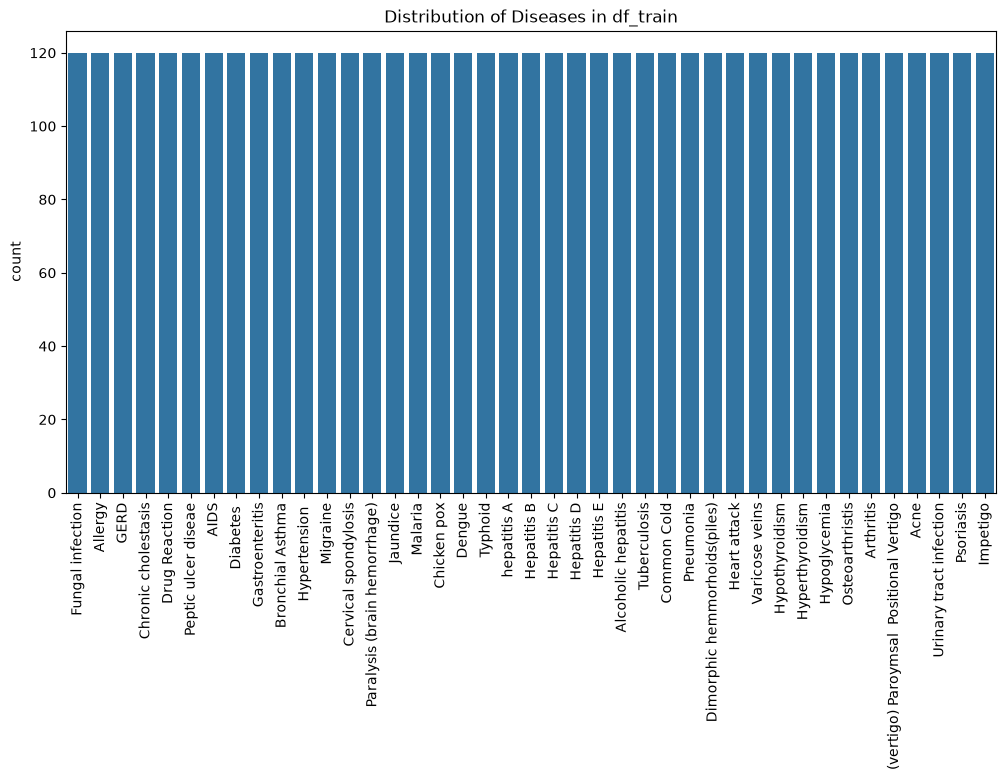

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

disease_names = encoder.inverse_transform(df_train["prognosis"])

plt.figure(figsize=(12, 6))
sns.countplot(x=disease_names)
plt.xticks(rotation=90)
plt.title("Distribution of Diseases in df_train")
plt.show()

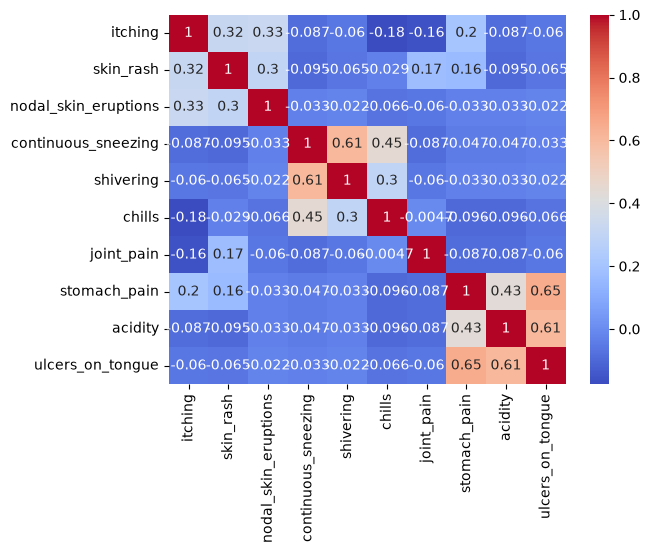

In [44]:
smaple_features = df_train.iloc[:, :10]
plt.Figure(figsize=(10, 8))
sns.heatmap(smaple_features.corr(), annot=True, cmap="coolwarm")
plt.show()